# **Estadística computacional - Grupo B**

**Integrantes:**

- Cristóbal Flores Campusano 

  Rol: 202473111-4
- Joaquín Solís Quintanilla 

  Rol: 202404077-4

- Josefa Vidal Toro

  Rol: 202373047-5
  
- Zi Xuan He

  Rol: 202473090-8


# **Entrega #1: Análisis Exploratorio de Datos**


## Introducción:

Información Relevante del Dataset:

Nuestro estudio se centrará en el análisis de un conjunto de datos que contiene información sobre las ventas de los videojuegos a nivel global. Este dataset corresponde a un conjunto de datos ampliamente utilizado para el análisis exploratorio, ya que recopila información sobre los videojuegos de distintas plataformas y géneros.

El dataset cuenta con aproximadamente 16.598 registros y 11 variables, lo que nos va a permitir realizar un análisis representativo con respecto al mercado de videojuegos. El uso efectivo de registros en el análisis corresponde a 16.326, este número es menor al inicial, ya que durante el proceso se aplicaron herramientas y procesos de limpieza de datos.

El dataset incluye las siguientes variables:

- Rank: Posición de los videojuegos según su venta global.

- Name: Corresponde al nombre del videojuego.

- Platform: Indica la plataforma en la que fue lanzado el videojuego.

- Year: Año de lanzamiento.

- Genre: Género al que pertenece.

- Publisher: Empresa encargada de publicar el videojuego.

- NA_Sales, EU_Sales, JP_Sales, Other_Sales: Ventas de los videojuegos en distintas regiones del mundo (Norteamérica, Europa, Japón y otras regiones).

- Global_Sales: Ventas totales del videojuego globalmente.

Clasificación de variables:

- La variable "Rank" es de tipo cuantitativa ordinal, ya que representa una posición dentro de un ranking.

- Las variables "Name, Platform, Publisher y Genre" son del tipo categórico.

- Las variables "Year, NA_Sales, EU_Sales, JP_Sales, Other_Sales y Global_Sales" son del tipo cuantitativo.

¿Por qué elegimos este dataset?

Elegimos este dataset porque abarca una temática cercana a nuestros intereses y formación, ya que como estudiantes informáticos consideramos que la industria de los videojuegos representa un papel muy relevante dentro del campo, tanto desde el punto tecnológico como comercial. Además, los videojuegos y su industria en general, han estado evolucionando constantemente a lo largo del tiempo, lo que aumenta nuestro interés por analizar su impacto en el mercado.


# Limpieza de Datos:


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
data= pd.read_csv("vgsales.csv")
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


**Revisión inicial del dataset:**

Antes de comenzar con el análisis exploratorio, se realizó una revisión general del dataset con el objetivo de encontrar posibles problemas o inconsistencias en este, tales como datos faltantes, registros duplicados y tipos de variables. Esta parte es crucial, ya que nos permite trabajar con datos más consistentes y adecuados sin provocar alteraciones al análisis.

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


**Valores faltantes:**

Tras realizar una inspección inicial del conjunto de datos mediante la función isnull().sum(), se ha detectado la presencia de valores nulos concentrados principalmente en las variables 'Year' y 'Publisher'. La existencia de estos vacíos representa un problema para la integridad del análisis, por lo cual se requiere una etapa previa de limpieza para evitar conflictos en las tendencias de ventas.

In [27]:
data.isnull().sum() # Revisa si hay registros nulos en las columnas, y los suma.

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

**Procedimiento de limpieza:**

A partir de la revisión inicial, se observó que el dataset contiene 16.598 registros y 11 variables. Además, se identificaron valores faltantes en las variables "Year" y "Publisher". Dado que este análisis considera a "Year" como variable relevante, se decidió eliminar los registros (filas) que no contaban con información de dicha variable. En cambio, la variable "Publisher" no será considerada dentro del análisis principal, por lo que se optó por eliminar esta columna del dataset, ya que su ausencia no afecta al resto de las variables utilizadas.

In [ ]:
# Eliminación de la columna Publisher.
data= data.drop(columns=['Publisher'])

# Eliminación de registros con valores faltantes en Year.
data= data.dropna(subset=['Year']).copy()

# Revisión de duplicados (se filtran las filas con nombre, plataforma, año y género idénticos).
duplicados= data[data.duplicated(subset= ['Name','Platform','Year','Genre'], keep=False)]
print(f"Se encontraron {len(duplicados)} filas duplicadas.")

# Eliminación de los datos duplicados (se conserva el mejor ranking).
filas_antes= len(data)
data= data.drop_duplicates(subset= ['Name', 'Platform', 'Year', 'Genre'], keep= 'first').copy()
eliminadas= filas_antes-len(data)

# Se indica que se eliminó 1 fila duplicada, ya que se mantuvo la de mayor raking.
print(f"Se eliminaron {eliminadas} filas duplicadas del dataset.")


Se encontraron 2 filas duplicadas.
Se eliminaron 1 filas duplicadas del dataset.


**Verificación del dataset:**

Se utilizó la función .info() para validar la estructura de los datos tras la depuración. El resultado confirma un total de 16.326 registros y la correcta tipificación de las variables numéricas y categóricas, asegurando un buen conjunto de datos para los cálculos estadísticos posteriores.

In [6]:
# Muestra una mini tabla de la información recopilada que tiene el dataset.
data.info()

<class 'pandas.DataFrame'>
Index: 16326 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16326 non-null  int64  
 1   Name          16326 non-null  str    
 2   Platform      16326 non-null  str    
 3   Year          16326 non-null  float64
 4   Genre         16326 non-null  str    
 5   NA_Sales      16326 non-null  float64
 6   EU_Sales      16326 non-null  float64
 7   JP_Sales      16326 non-null  float64
 8   Other_Sales   16326 non-null  float64
 9   Global_Sales  16326 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 1.4 MB


**Verificación de los valores faltantes después de la limpieza:**

Para asegurarnos de que no quedaran registros nulos, se realizó un conteo de estos valores mediante .isnull().sum(). Como se puede observar, la tabla nos indica que no existen registros nulos, por lo que nos asegura que las visualizaciones de las tendencias y las comparaciones regionales no presenten datos nulos.

In [7]:
# Revisa si hay registros nulos por cada variables y los suma.
data.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

**Resultado de la limpieza:**

Luego del proceso de limpieza, el dataset quedó conformado por 16.326 registros y 10 variables.

En resumen:
- Se eliminó la columna "Publisher".

- Se eliminaron los registros faltantes en "Year".

- Se eliminaron registros duplicados detectados.

**Variables Principales y Secundarias:**

Considerando el dataset, a continuación se presentan las variables principales y secundarias seleccionadas para este análisis. Esta elección se realizó en base a los patrones observados durante el EDA, enfocado en el trabajo de las variables más relevantes.

Variables Principales: Se consideraron las variables "Genre" (género) y "JP_Sales" (ventas de Japón) como las principales. Por un lado, Genre es primordial porque, a partir del EDA, se observó que las ventas de los videojuegos no se comportan de igual manera en todos los géneros, lo que nos permite analizar distintos tipos de patrones. Por otra parte, JP_Sales fue seleccionada como principal debido a que Japón se destacó como una región especialmente interesante, mostrando un comportamiento distinto al de otras regiones en varios géneros.

Variables Secundarias: Se consideraron las variables "EU_Sales" (ventas de Europa) y "NA_Sales" (ventas de Norteamérica) como las secundarias. La variable EU_Sales permite establecer una comparación con Japón a partir de otro mercado importante dentro de la industria de los videojuegos. De manera similar, NA_Sales se incluyó porque representa una de las regiones más relevantes del dataset en términos de ventas, por lo que su comparación permite contrastar si el comportamiento observado es particular o si también se repite frente a otro.

# Analisis Univariados


## Frecuencia de Géneros de juegos:

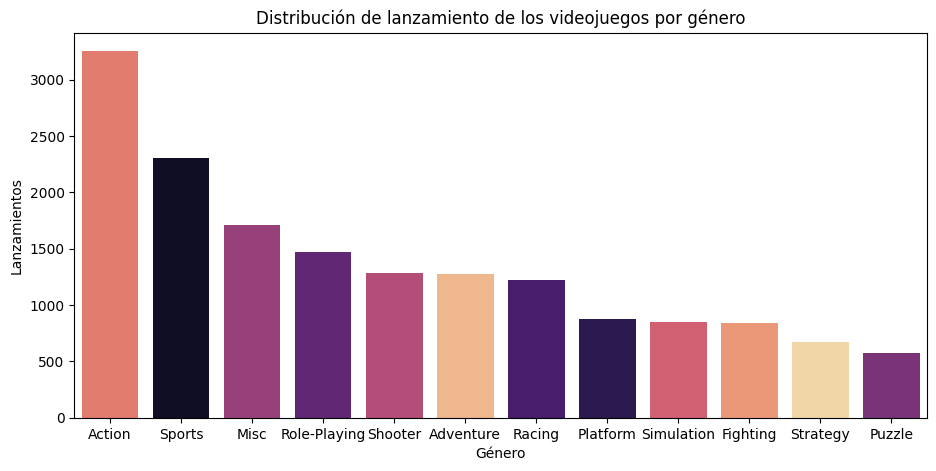

In [ ]:
plt.figure(figsize= (11,5)) # Tamaño del lienzo del gráfico.
sns.countplot(data= data, x= 'Genre', order= data['Genre'].value_counts().index, palette= 'magma', legend= False, hue='Genre' ) # Gráfico de Barras contando la frecuencia por género, con la paleta de colores magma.
plt.title('Distribución de lanzamiento de los videojuegos por género') # Título del gráfico.
plt.ylabel('Lanzamientos') # Título del eje y.
plt.xlabel('Género') # Título del eje x.
plt.show() # Muestra el gráfico.

Se observa que el género Action es el más frecuente del dataset, seguido por Sports. En cambio, los géneros como Puzzle y Strategy presentan una menor cantidad, lo que nos indica que la distribución de los datos no es homogénea.

## Frecuencia Absoluta de plataformas de juegos:

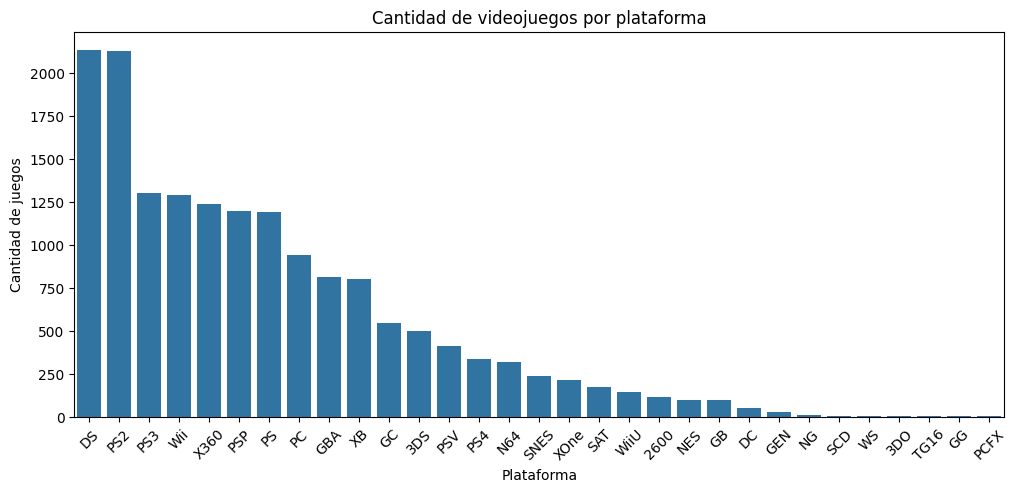

In [ ]:
plt.figure(figsize=(12,5)) # Tamaño del lienzo del gráfico.
sns.countplot(data =data, x='Platform', order= data['Platform'].value_counts().index) # Diagrama de barras para visualizar la frecuencia absoluta (cantidad de videojuegos lanzado por plataforma).
plt.xticks(rotation= 45) # Rotamos las etiquetas del eje x, para evitar que los nombres se amontonen.
plt.title('Cantidad de videojuegos por plataforma') # Título del gráfico.
plt.xlabel('Plataforma') # Título del eje x.
plt.ylabel('Cantidad de juegos') # Título del eje y.
plt.show() # Muestra el gráfico.


Se observa que algunas plataformas concentran una mayor cantidad de videojuegos que otras, esto nos dice que, la presencia de títulos dentro del dataset no se distribuye de forma uniforme entre las plataformas, lo que puede influir en los análisis posteriores relacionados con las ventas.

## Análisis de lanzamientos de videojuegos a través de los años:

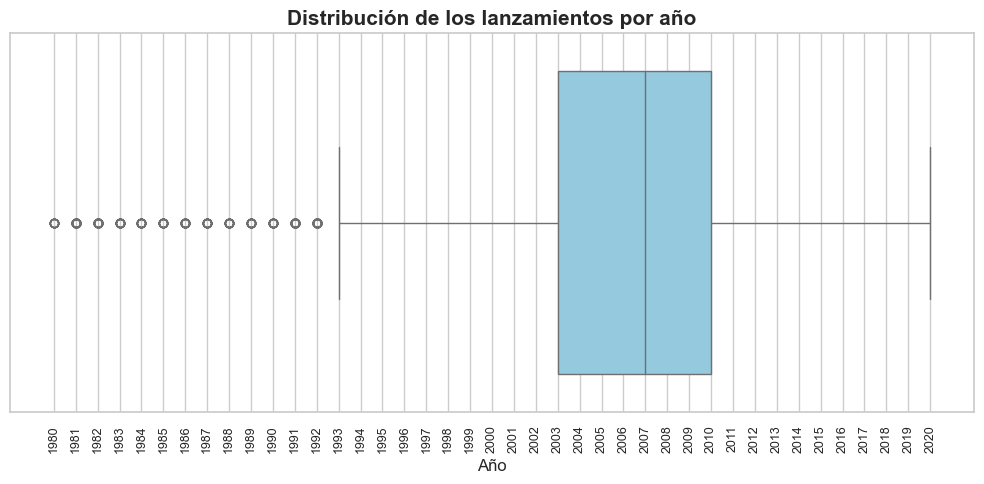

In [ ]:
sns.set_theme(style= "whitegrid") # Tema visual con fondo blanco y rejilla para facilitar la lectura de los valores.
data['Year']= data['Year'].astype(int) # Convertir la columna a int.
plt.figure(figsize= (10,5)) # Definir el tamaño del gráfico.
sns.boxplot(x= data['Year'],color= "skyblue") # Crear boxplot para visualizar la distribución del año y detectar los valores atípicos.

agno_min= data['Year'].min() # Encuentra el menor año de la columna 'Year'.
agno_max= data['Year'].max() # Encuetra el mayor año de la columna 'Year'.

plt.xticks(range(agno_min,agno_max +1, 1), rotation= 90, fontsize= 9) # Muestra todos los años uno por uno.
plt.title('Distribución de los lanzamientos por año', fontsize= 15, fontweight= 'bold') # Título principal del gráfico.
plt.xlabel('Año') # Título del eje x.
plt.tight_layout() # Autoajusta los márgenes y espacios entre las etiquetas.
plt.show() # Muestra el gráfico.


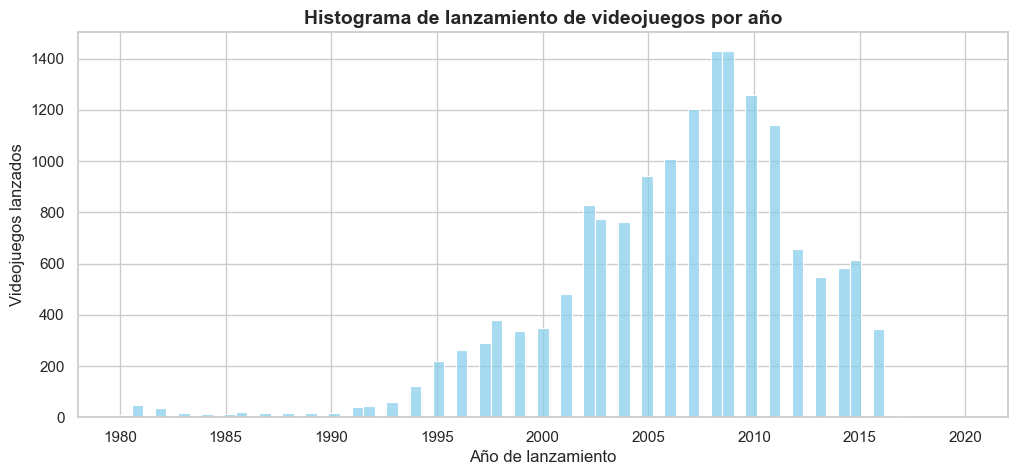

In [ ]:
plt.figure(figsize= (12, 5)) # Tamaño del lienzo del gráfico.
sns.histplot(x= data['Year'], color= 'skyblue') # Histograma del lanzamiento de videojuegos por año.
plt.title('Histograma de lanzamiento de videojuegos por año', fontsize= 14, fontweight= 'bold') # Título del gráfico.
plt.xlabel('Año de lanzamiento', fontsize= 12) # Título eje x.
plt.ylabel('Videojuegos lanzados', fontsize= 12) # Título del eje y.
plt.show() # Muestra el gráfico.

A partir del **Diagrama de Boxplot**, se puede observar una caja rectangular que representa el periodo donde hubieron más lanzamiento de juegos (2003-2010). Este hallazgo se correlaciona directamente con el **Histograma**, en donde se muestra una clara acumulación de las barras en ese mismo rango de años.

Es relevante destacar el crecimiento sostenido de la industria de los videojuegos a partir del 1993, ya que este fenómeno se puede interpretar como un auge para la industria. Respecto a la caída observada en el año 2011, no se puede afirmar que hubo una disminución en los lanzamientos.

La linea negra vertical que se encuentra dentro del rectángulo azul representa a la mediana (2007). Por otro lado, los puntos aislados en la izquierda representan a los outliers, en el periodo de los años 1980-1993 aproximadamente, analizando el histograma, la gráfica presenta una asimetría negativa (datos concentrados más hacia la derecha) con la ubicación de la mediana (2007), la cual está muy cerca del tope máximo de lanzamientos, esto nos revela una alta densidad de productividad en la industria de videosjuegos en la etapa moderna o al final del dataset.

## Análisis de Ventas:

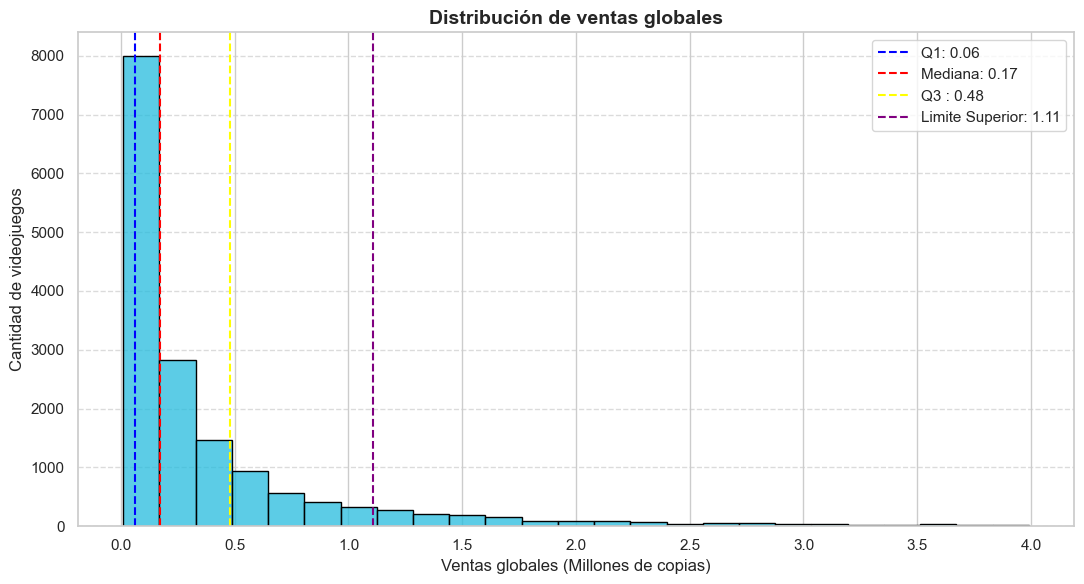

In [ ]:
plt.figure(figsize= (11,6)) # Tamaño del lienzo del gráfico.
q1= data['Global_Sales'].quantile(0.25) # Calcula el primer cuartil de las ventas en el mundo.
mediana= data['Global_Sales'].quantile(0.50) # Calcula la mediana de las ventas en el  mundo.
q3= data['Global_Sales'].quantile(0.75) # Calcula el tercer cuartil de las ventas en el mundo.
rango_intercuartilico= q3-q1 # Rango intercuartílico.
limite_superior= q3+1.5*rango_intercuartilico # Límite superior.

datos_filtrados= data[data['Global_Sales'] < 4]['Global_Sales'] # Para una mejor apreciación del gráfico, solo ocupamos los datos que son menores a 4 millones.

sns.histplot(datos_filtrados, bins =25, color= "#25bcde", edgecolor= 'black') # Genera un histograma con 25 barras de color azul claro y bordes negro.

plt.axvline(q1, color= 'blue', linestyle= '--', label= f'Q1: {q1:.2f}') # Dibuja una línea azul discontinua para marcar el primer cuartil y la añade a la leyenda.
plt.axvline(mediana, color= 'red', linestyle= '--', label= f'Mediana: {mediana:.2f}') # Dibuja una línea roja discontinua para marcar la mediana y la añade a la leyenda.
plt.axvline(q3, color= 'yellow', linestyle= '--', label= f'Q3 : {q3:.2f}') # Dibuja una línea amarilla discontinua para marcar el tercer cuartil y la añade a la leyenda.
plt.axvline(limite_superior, color= 'purple', linestyle= '--', label= f'Limite Superior: {limite_superior:.2f}') # Dibuja una línea morada discontinua para marcar el límite superior y la añade a la leyenda.

plt.title('Distribución de ventas globales', fontsize= 14, fontweight= 'bold') # Título del gráfico.
plt.xlabel('Ventas globales (Millones de copias)', fontsize= 12) # Título del eje x.
plt.ylabel('Cantidad de videojuegos', fontsize= 12) # Título del eje y.
plt.grid(axis='y', linestyle='--',alpha=0.7) # Cuadrícula horizontal con transparencia del 70%.

plt.legend() # Muestra la leyenda del gráfico.
plt.tight_layout() # Autoajusta los márgenes y espacios entre las etiquetas.
plt.show() # Muestra el gráfico.

Se pude visualizar que la mayoría de los videojuegos presentan ventas bajas y son pocos los juegos que alcanzan valores altos. Además, la mediana (0,17) es considerablemente menor al límite superior de los outliers (1,11), lo que señala que el mercado global está marcado por pocos títulos muy exitosos y una gran cantidad con desempeños bajos.

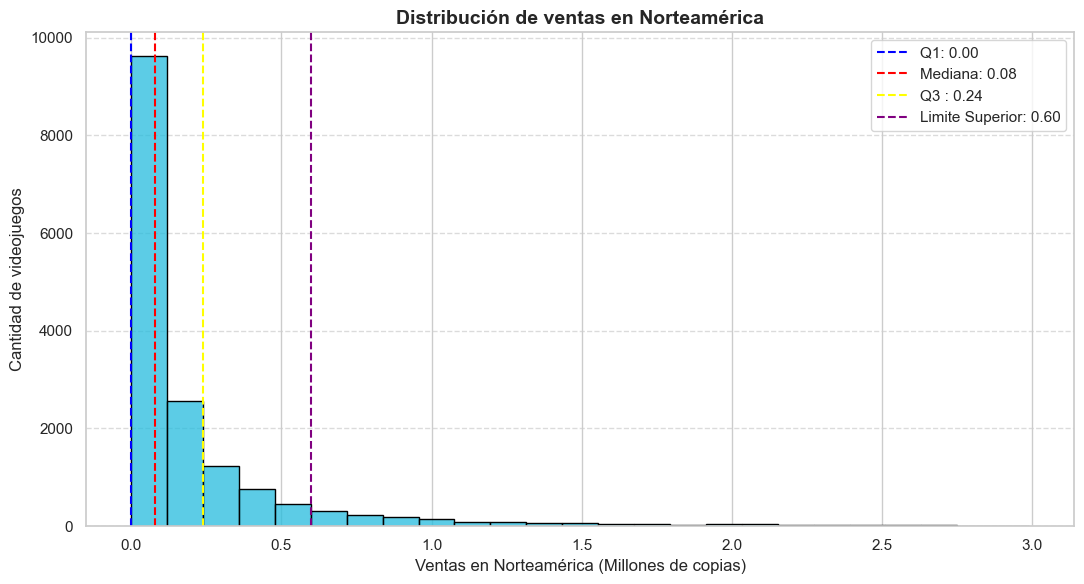

In [ ]:
plt.figure(figsize= (11, 6)) # Tamaño del lienzo del gráfico.
q1= data['NA_Sales'].quantile(0.25) # Calcula el primer cuartil de las ventas en Norteamérica.
mediana= data['NA_Sales'].quantile(0.50) # Calcula la mediana de las ventas en Norteamérica.
q3= data['NA_Sales'].quantile(0.75) # Calcula el tercer cuartil de las ventas en Norteamérica.
rango_intercuartilico= q3-q1 # Rango intercuartílico.
limite_superior= q3+1.5*rango_intercuartilico# Límite superior.

datos_filtrados= data[data['NA_Sales'] < 3]['NA_Sales'] # Para una mejor apreciación del gráfico, solo ocupamos los datos que son menores a 3 millones.

sns.histplot(datos_filtrados, bins =25, color= "#25bcde", edgecolor= 'black') # Generar un histograma con 25 barras de color azul claro y bordes negro.

plt.axvline(q1, color= 'blue', linestyle= '--', label= f'Q1: {q1:.2f}') # Dibuja una línea azul discontinua para marcar el primer cuartil y la añade a la leyenda.
plt.axvline(mediana, color= 'red', linestyle= '--', label= f'Mediana: {mediana:.2f}') # Dibuja una línea roja discontinua para marcar la mediana y la añade a la leyenda.
plt.axvline(q3, color= 'yellow', linestyle= '--', label= f'Q3 : {q3:.2f}') # Dibuja una línea amarilla discontinua para marcar el tercer cuartil y la añade a la leyenda.
plt.axvline(limite_superior, color= 'purple', linestyle= '--', label= f'Limite Superior: {limite_superior:.2f}') # Dibuja una línea morada discontinua para marcar el límite superior y la añade a la leyenda.

plt.title('Distribución de ventas en Norteamérica', fontsize= 14, fontweight= 'bold') # Título del gráfico.
plt.xlabel('Ventas en Norteamérica (Millones de copias)', fontsize= 12) # Título del eje x.
plt.ylabel('Cantidad de videojuegos', fontsize= 12) # Título del eje y.
plt.grid(axis='y', linestyle='--',alpha=0.7) # Cuadrícula horizontal con transparencia del 70%.

plt.legend() # Muestra la leyenda del gráfico.
plt.tight_layout() # Autoajusta los márgenes y espacios entre las etiquetas.
plt.show() # Muestra el gráfico.

El gráfico presenta una distribución similar a la de las ventas globales, la mayoría de videojuegos poseen ventas bajas y aparecen en menor cantidad aquellos con ventas altas, los que generan un gran impacto en el mercado.

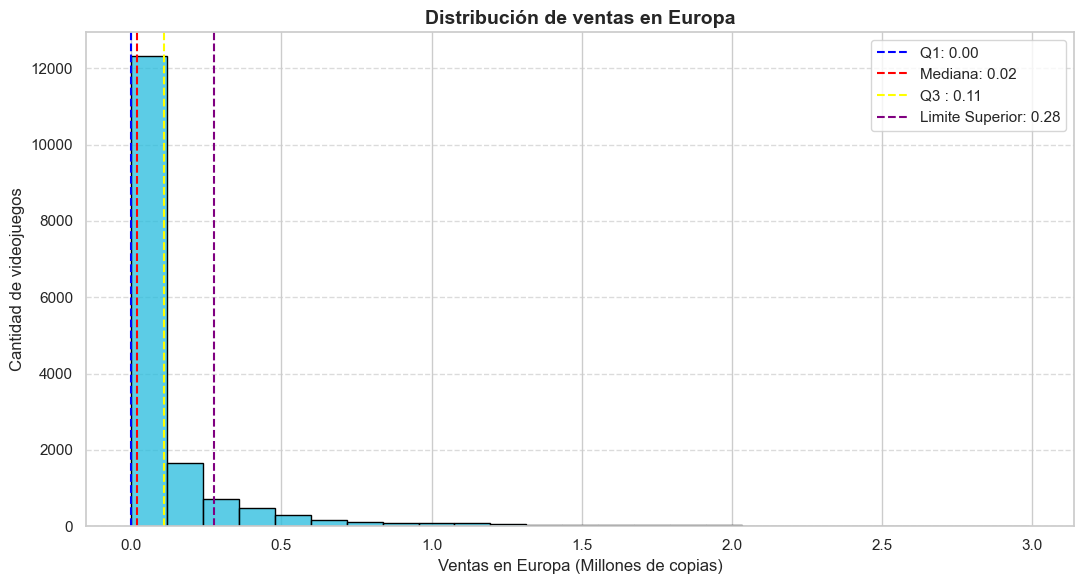

In [ ]:
plt.figure(figsize= (11, 6)) # Tamaño del lienzo del gráfico.
q1= data['EU_Sales'].quantile(0.25) # Calcula el primer cuartil de las ventas en Europa.
mediana= data['EU_Sales'].quantile(0.50) # Calcula la mediana de las ventas en Europa.
q3= data['EU_Sales'].quantile(0.75) # Calcula el tercer cuartil de las ventas en Europa.
rango_intercuartilico= q3 - q1 # Rango intercuartílico.
limite_superior= q3 +1.5*rango_intercuartilico # Límite superior.

datos_filtrados= data[data['EU_Sales'] < 3]['EU_Sales'] # Para una mejor apreciación del gráfico, solo ocupamos los datos que son menores a 3 millones.

sns.histplot(datos_filtrados, bins =25, color= "#25bcde", edgecolor= 'black') # Generar un histograma con 25 barras de color azul claro y bordes negro.

plt.axvline(q1, color= 'blue', linestyle= '--', label= f'Q1: {q1:.2f}') # Dibuja una línea azul discontinua para marcar el primer cuartil y la añade a la leyenda.
plt.axvline(mediana, color= 'red', linestyle= '--', label= f'Mediana: {mediana:.2f}') # Dibuja una línea roja discontinua para marcar la mediana y la añade a la leyenda.
plt.axvline(q3, color= 'yellow', linestyle= '--', label= f'Q3 : {q3:.2f}') # Dibuja una línea amarilla discontinua para marcar el tercer cuartil y la añade a la leyenda.
plt.axvline(limite_superior, color= 'purple', linestyle= '--', label= f'Limite Superior: {limite_superior:.2f}') # Dibuja una línea morada discontinua para marcar el límite superior y la añade a la leyenda. 

plt.title('Distribución de ventas en Europa', fontsize= 14, fontweight= 'bold') # Título del gráfico.
plt.xlabel('Ventas en Europa (Millones de copias)', fontsize= 12) # Título del eje x.
plt.ylabel('Cantidad de videojuegos', fontsize= 12) # Título del eje y.
plt.grid(axis='y', linestyle='--',alpha=0.7) # Cuadrícula horizontal con transparencia del 70%.

plt.legend() # Muestra la leyenda del gráfico.
plt.tight_layout() # Autoajusta los márgenes y espacios entre las etiquetas.
plt.show() # Muestra el gráfico.

En el mercado europeo se vuelve a observar que la mayoría de juegos poseen bajas ventas, aunque en comparación a los anteriores, el rango superior es incluso más acotado, lo que también indica que hay una menor dispersión en los videojuegos con mayores ventas.

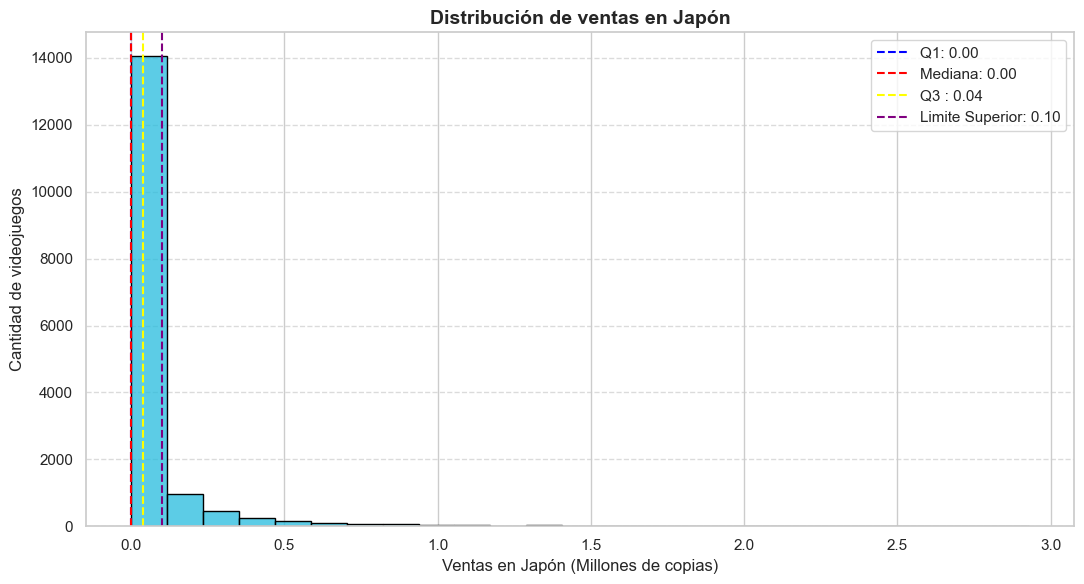

In [ ]:
plt.figure(figsize= (11, 6)) # Tamaño del lienzo del gráfico.
q1= data['JP_Sales'].quantile(0.25) # Calcula el primer cuartil de las ventas en Japón.
mediana= data['JP_Sales'].quantile(0.50) # Calcula la mediana de las ventas en Japón.
q3= data['JP_Sales'].quantile(0.75) # Calcula el tercer cuartil de las ventas en Japón.
rango_intercuartilico= q3-q1 # Rango intercuartílico. 
limite_superior= q3+1.5*rango_intercuartilico # Límite superior.

datos_filtrados= data[data['JP_Sales'] < 3]['JP_Sales'] # Para una mejor apreciación del gráfico, solo ocupamos los datos que son menores a 3 millones.

sns.histplot(datos_filtrados, bins =25, color= "#25bcde", edgecolor= 'black') # Generar un histograma con 25 barras de color azul claro y bordes negros.

plt.axvline(q1, color= 'blue', linestyle= '--', label= f'Q1: {q1:.2f}') # Dibuja una línea azul discontinua para marcar el primer cuartil y la añade a la leyenda.
plt.axvline(mediana, color= 'red', linestyle= '--', label= f'Mediana: {mediana:.2f}') # Dibuja una línea roja discontinua para marcar la mediana y la añade a la leyenda.
plt.axvline(q3, color= 'yellow', linestyle= '--', label= f'Q3 : {q3:.2f}') # Dibuja una línea amarilla discontinua para marcar el tercer cuartil y la añade a la leyenda.
plt.axvline(limite_superior, color= 'purple', linestyle= '--', label= f'Limite Superior: {limite_superior:.2f}') # Dibuja una línea morada discontinua para marcar el límite superior y la añade a la leyenda. 

plt.title('Distribución de ventas en Japón', fontsize= 14, fontweight= 'bold') # Título del gráfico.
plt.xlabel('Ventas en Japón (Millones de copias)', fontsize= 12) # Título del eje x.
plt.ylabel('Cantidad de videojuegos', fontsize= 12) # Título del eje y.
plt.grid(axis='y', linestyle='--',alpha=0.7) # Cuadrícula horizontal con transparencia del 70%.

plt.legend() # Muestra la leyenda del gráfico.
plt.tight_layout() # Autoajusta los márgenes y espacios entre las etiquetas.
plt.show() # Muestra el gráfico.

La distribución de ventas del mercado japonés sigue la tendencia de los anteriores, la mayoría de juegos posee ventas bajas y el éxito en ventas se concentra en una pequeña cantidad de videojuegos.

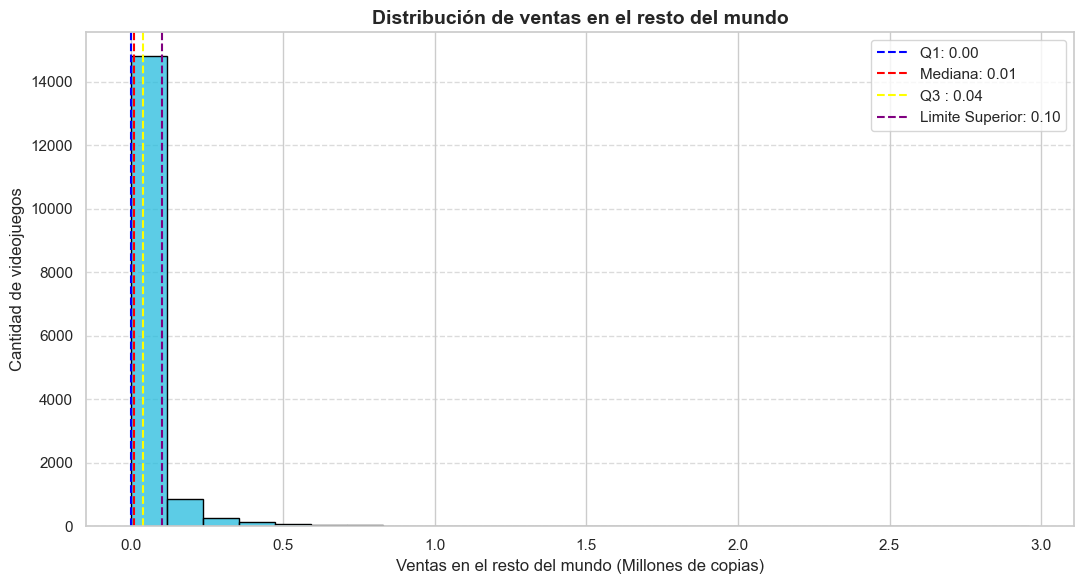

In [ ]:

plt.figure(figsize= (11, 6)) # Tamaño del lienzo del gráfico.
q1= data['Other_Sales'].quantile(0.25) # Calcula el primer cuartil de las ventas en el resto del mundo.
mediana= data['Other_Sales'].quantile(0.50) # Calcula la mediana de las ventas en el resto del mundo.
q3= data['Other_Sales'].quantile(0.75) # Calcula el tercer cuartil de las ventas en el resto del mundo.
rango_intercuartilico= q3-q1 # Rango intercuartílico.
limite_superior= q3+1.5*rango_intercuartilico # Límite superior.

datos_filtrados= data[data['Other_Sales'] < 3]['Other_Sales'] # Para una mejor apreciación del gráfico, solo ocupamos los datos que son menores a 3 millones.

sns.histplot(datos_filtrados, bins =25, color= "#25bcde", edgecolor= 'black') # Generar un histograma con 25 barras de color azul claro y bordes negro.

plt.axvline(q1, color= 'blue', linestyle= '--', label= f'Q1: {q1:.2f}') # Dibuja una línea azul discontinua para marcar el primer cuartil y la añade a la leyenda.
plt.axvline(mediana, color= 'red', linestyle= '--', label= f'Mediana: {mediana:.2f}') # Dibuja una línea roja discontinua para marcar la mediana y la añade a la leyenda.
plt.axvline(q3, color= 'yellow', linestyle= '--', label= f'Q3 : {q3:.2f}') # Dibuja una línea amarilla discontinua para marcar el tercer cuartil y la añade a la leyenda.
plt.axvline(limite_superior, color= 'purple', linestyle= '--', label= f'Limite Superior: {limite_superior:.2f}') # Dibuja una línea morada discontinua para marcar el límite superior y la añade a la leyenda.

plt.title('Distribución de ventas en el resto del mundo', fontsize= 14, fontweight= 'bold') # Título del gráfico.
plt.xlabel('Ventas en el resto del mundo (Millones de copias)', fontsize= 12) # Título del eje x.
plt.ylabel('Cantidad de videojuegos', fontsize= 12) # Título del eje y.
plt.grid(axis='y', linestyle='--',alpha=0.7) # Cuadrícula horizontal con transparencia del 70%.

plt.legend() # Muestra la leyenda del gráfico
plt.tight_layout() # Autoajusta los márgenes y espacios entre las etiquetas.
plt.show() # Muestra el gráfico.

En el resto del mundo, las ventas son menores en general y existe menor variación entre los videojuegos. Se destaca la ausencia de valores extremos, lo que sugiere que este mercado no está impulsado por éxitos comerciales, a diferencia de otros.

# Analisis Multivariados:

## Análisis de las ventas según el género de los videojuegos:

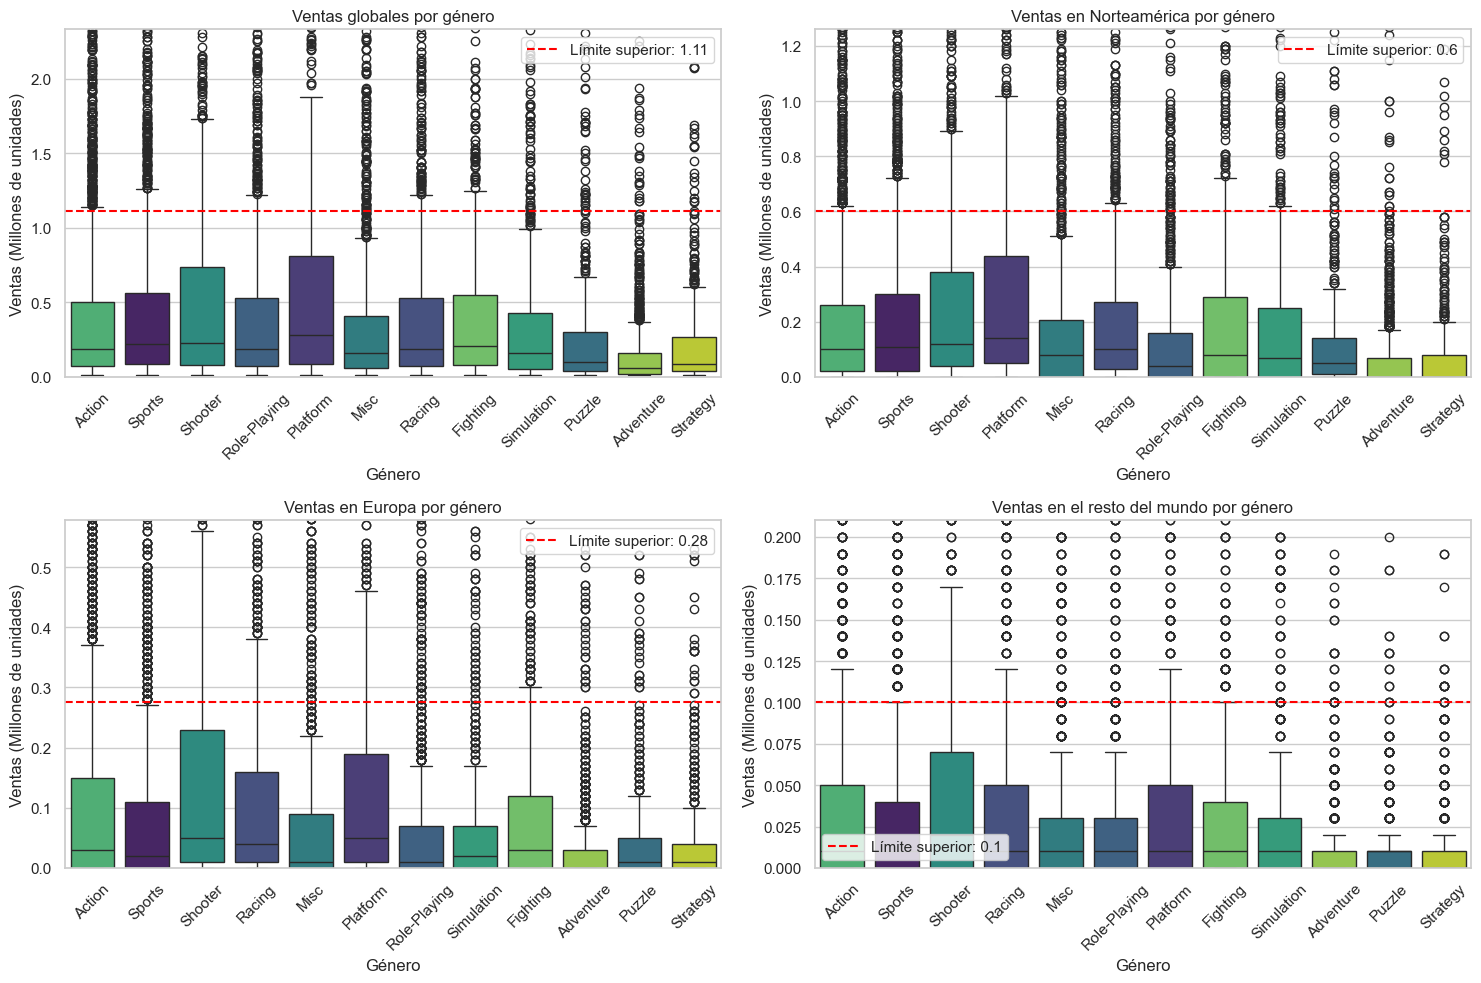

In [ ]:
# Se crea una cuadrícula 2x2 para los 4 gráficos y se ajusta su tamaño.
figura, ejes= plt.subplots(2,2,figsize= (15,10))

# Se definen las columnas de venta y los títulos para cada uno.
variables= ["Global_Sales", "NA_Sales", "EU_Sales", "Other_Sales"]
titulos= ["Ventas globales por género", "Ventas en Norteamérica por género", "Ventas en Europa por género", "Ventas en el resto del mundo por género"]

# Recorremos sobre cada eje de la cuadrícula.
for i, j in enumerate(ejes.flat):

    # Se elige la columna de ventas que toca en este recorrido.
    columna_ventas= variables[i]

    # Se ordenan los géneros de mayor a menor según sus ventas totales.
    orden= data.groupby("Genre")[columna_ventas].sum().sort_values(ascending= False).index

    # Se dibuja el gráfico.
    sns.boxplot(data= data, x= "Genre", y= columna_ventas, palette= "viridis", hue= "Genre", legend= False, order= orden, ax=j)

    # Se calcula la línea roja
    q1= data[columna_ventas].quantile(0.25) # El 25% de los datos.
    q3= data[columna_ventas].quantile(0.75) # El 75% de los datos.
    resta= q3-q1                            # Distancia entre ellos.
    limite_superior= q3+1.5*resta           # Marca el tope de ventas "normales".

    # Retoques visuales, se ponen los títulos y los nombres de cada lado del gráfico.
    j.set_ylim(0, limite_superior*2.1)
    j.axhline(y= limite_superior, color= "red", linestyle= "--", label= "Límite superior: " + str(round(limite_superior, 2)))
    j.set_title(titulos[i], fontsize= 12)
    j.set_xlabel("Género")
    j.set_ylabel("Ventas (Millones de unidades)")
    j.tick_params(axis= "x", rotation= 45)
    j.legend()

# Se ajusta el espacio entre los 4 gráficos para que no se superpongan y se muestra el gráfico final.
plt.tight_layout()
plt.show()

Se observan diferencias en la cantidad de ventas por género, donde Platform y Shooter presentan las mayores, al contrario de Adventure y Strategy, que presentan las menores. 

Además se evidencia la presencia de variabilidad y outliers, que corresponden a éxitos en ventas, en todos los géneros, de lo que una posible inferencia es que el éxito de un videojuego no depende exclusivamente del género al que pertenezca.

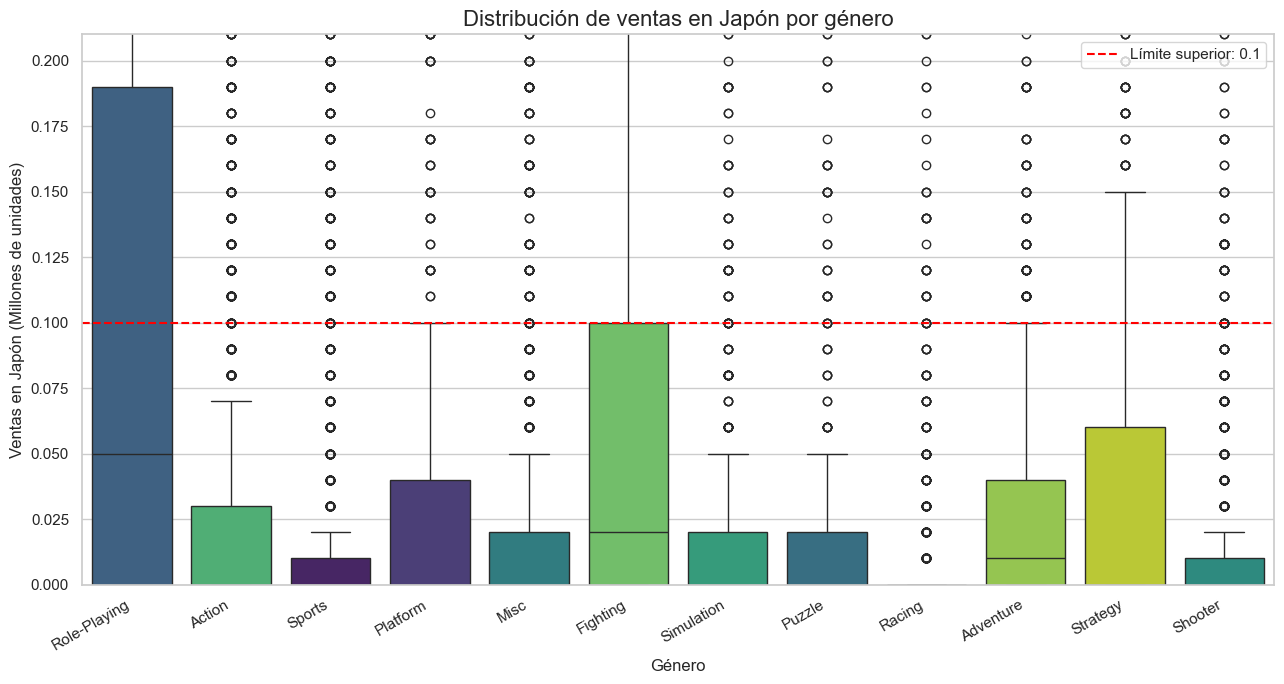

In [ ]:
# Tamaño del lienzo del gráfico.
plt.figure(figsize= (13, 7))

# Se dibuja el gráfico de cajas para las ventas en Japón y los géneros aparecerán ordenados de mayor a menor según sus ventas totales.
sns.boxplot(data= data, x= 'Genre', y= 'JP_Sales', palette= "viridis", hue= "Genre", legend= False, order= data.groupby('Genre')['JP_Sales'].sum().sort_values(ascending= False).index)

# Se pone el título y los nombres a los ejes.
plt.title('Distribución de ventas en Japón por género', fontsize= 16)
plt.ylabel('Ventas en Japón (Millones de unidades)', fontsize= 12)
plt.xlabel('Género', fontsize= 12)

# Se giran los nombres de los géneros para una mejor visualización.
plt.xticks(rotation= 30, ha= 'right')

# Se calcula la línea roja.
q1= data['JP_Sales'].quantile(0.25) # Punto donde empieza la caja.
q3= data['JP_Sales'].quantile(0.75) # Punto donde termina la caja.
resta= q3-q1 # Ancho de la caja (rango intercuartil).

# Fórmula para marcar el límite de las ventas "normales".
limite_superior= q3+1.5*resta

# Ajustes visuales, se dibuja la línea roja, se le pone su etiqueta y se muestra el gráfico final.
plt.ylim(0, limite_superior*2.1)
plt.axhline(y= limite_superior, color= "red", linestyle= "--", label= "Límite superior: " + str(round(limite_superior, 2)))
plt.legend(loc= 'upper right', bbox_to_anchor= (1,1))
plt.tight_layout()
plt.show()

El gráfico de cajas confirma que el mercado japonés tiene una estructura de consumo única, liderada por el género Role-Playing, que presenta la mayor distribución de éxito comercial. En contraste, géneros que son tendencias como Shooter y Sports muestran cajas extremadamente comprimidas cerca del eje cero, lo que indica que la gran mayoría de sus títulos tienen un impacto mínimo en esta región. Asimismo, la presencia masiva de outliers en todos los géneros sugiere que, independientemente del promedio, el mercado japonés sigue siendo capaz de producir éxitos individuales aislados en categorías menos populares.

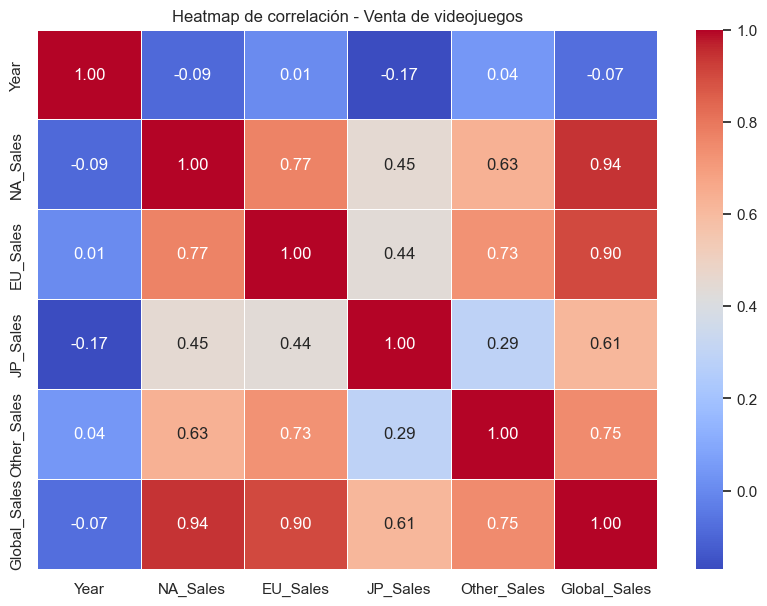

In [19]:
# Se seleccionan solo las columnas que tienen números y se quita la columna Rank porque es solo un número en la lista y no sirve para comparar.
data_num= data.select_dtypes(include= ["number"]).drop(columns= ["Rank"])

# Se calcula la correlacion (operación que mide qué tan parecidas son dos columnas).
correlacion= data_num.corr()

# Tamaño del lienzo del gráfico, ajustes visuales, se pone el título y se muestra el resultado.
plt.figure(figsize= (10,7))
sns.heatmap(correlacion, annot= True, cmap= "coolwarm", fmt= ".2f", linewidths= 0.5)
plt.title("Heatmap de correlación - Venta de videojuegos")
plt.show()

El Heatmap de correlación confirma que las ventas globales están ligadas casi en su totalidad al éxito en Norteamérica (0.94) y Europa (0.90). No obstante, destaca la correlación negativa entre el Año y las Ventas, lo que sugiere un decrecimiento del mercado físico con el paso del tiempo. Además, Japón presenta el coeficiente más bajo respecto a las ventas globales (0.61), lo que confirma estadísticamente su independencia comercial y una diferencia de sus tendencias de consumo frente a occidente.

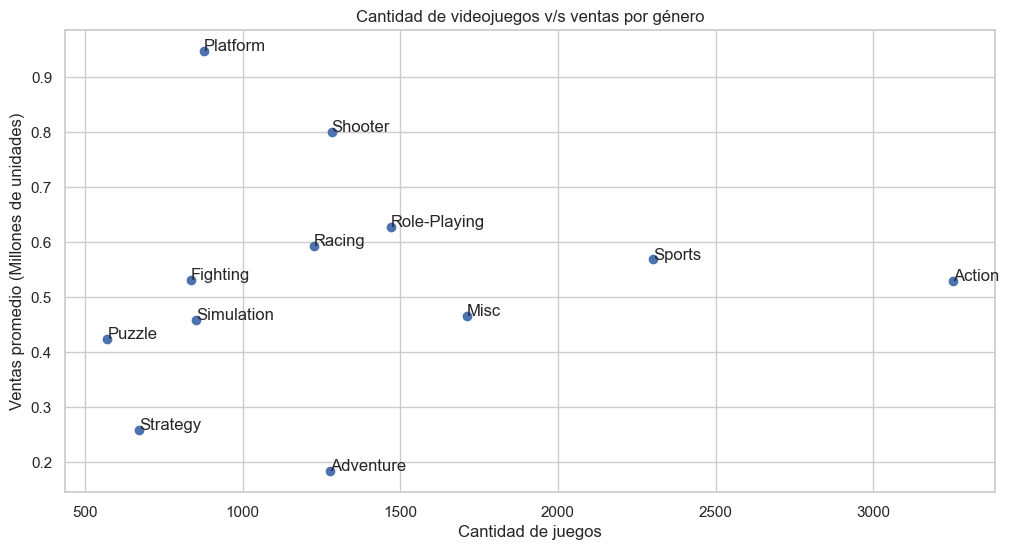

In [20]:
# Calculamos el promedio de ventas por cada género.
ventas= data.groupby("Genre")["Global_Sales"].mean()

# Se cuentan los juegos existentes de cada género.
cantidad= data["Genre"].value_counts()

# Se juntan ambos datos (promedio y cantidad) en una nueva tabla.
resumen_genero= ventas.to_frame()
resumen_genero["Cantidad"]= cantidad

# Tamaño del lienzo del gráfico y se dibujan los puntos de dispersión.
plt.figure(figsize= (12, 6))
plt.scatter(resumen_genero["Cantidad"], resumen_genero["Global_Sales"])

# Se le pone el nombre del género a cada punto para identificarlos.
for i in resumen_genero.index:
    plt.text(resumen_genero["Cantidad"][i], resumen_genero["Global_Sales"][i], i)

# Se ponen los nombres de los ejes, el título del gráfico y se muestra el resultado.
plt.xlabel("Cantidad de juegos")
plt.ylabel("Ventas promedio (Millones de unidades)")
plt.title("Cantidad de videojuegos v/s ventas por género")
plt.show()

Este gráfico revela que no existe una relación directa entre producir más juegos y vender más por cada uno. Se identifican géneros saturados como Action, donde la altísima oferta de títulos diluye el promedio de ventas. Por otro lado, géneros como Platform y Shooter demuestran una mayor eficiencia comercial, ya que con una menor cantidad de lanzamientos logran promedios de ventas significativamente superiores. Finalmente, géneros como Adventure se posicionan como mercados de nicho, con baja producción y un retorno promedio menor en comparación con las categorías líderes.

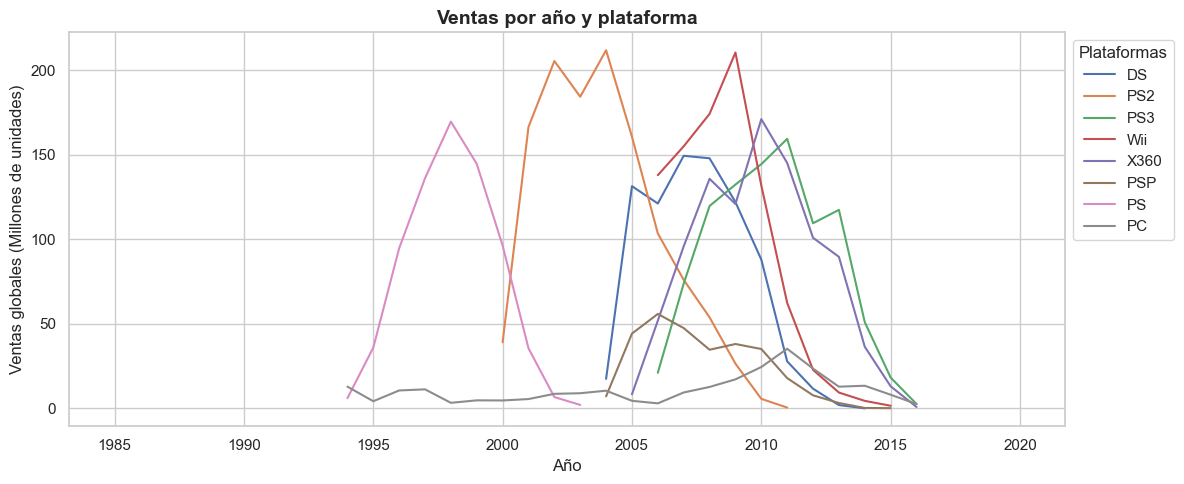

In [ ]:
# Tamaño del lienzo del gráfico, columna_ventas es el espacio específico donde se dibujarán las líneas.
figura, columna_ventas= plt.subplots(figsize= (12, 5))

# Se crea una tabla que suma las ventas totales por cada año y plataforma.
tabla= data.groupby(["Year", "Platform"])["Global_Sales"].sum().unstack()

# Se identifican las 8 plataformas con más juegos registrados y se dibujan las líneas en el lienzo.
top= data["Platform"].value_counts().head(8).index
tabla= tabla[top]
tabla.plot(ax= columna_ventas)

# Se agregan títulos y los nombres de los ejes.
plt.title("Ventas por año y plataforma", fontsize= 14, fontweight= 'bold')
plt.xlabel("Año")
plt.ylabel("Ventas globales (Millones de unidades)")

# Se coloca la lista de pltaformas afuera del gráfico y se muestra el resultado.
plt.legend(title= "Plataformas", bbox_to_anchor= (1, 1), loc= 'upper left')
plt.tight_layout()
plt.show()

Este gráfico permite visualizar la evolución competitiva de las plataformas de hardware. Se observa claramente el ciclo de vida de cada consola, que suele durar entre 6 y 10 años. Es notable cómo el declive de una plataforma (como la PS2) coincide con el ascenso de la siguiente generación (PS3, Xbox 360 y Wii), lo que demuestra que la industria se mueve por saltos tecnológicos.

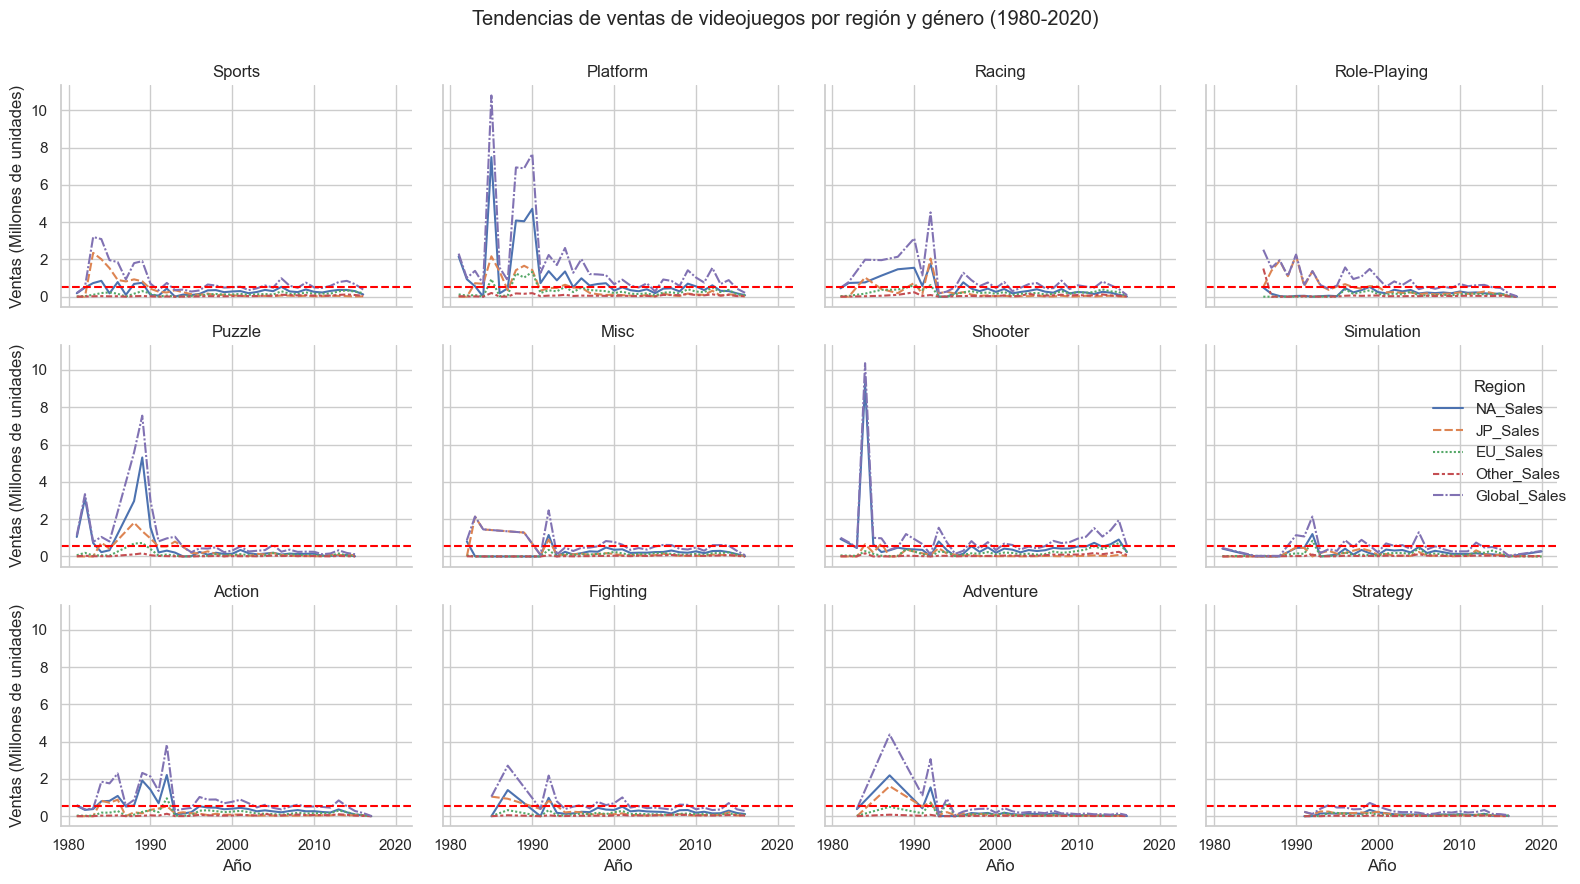

In [ ]:
# Pasamos las ventas de cada región a una sola columna para que se pueda comparar regiones usando diferentes colores.
ventas_formato= data.melt(id_vars= ['Year', 'Genre', 'Platform'], value_vars= ['NA_Sales', 'JP_Sales', 'EU_Sales', 'Other_Sales', 'Global_Sales'], var_name= 'Region', value_name= 'Sales')

# Se filtra para ver solamente los videojuegos del año 1980 en adelante.
filtro= ventas_formato[ventas_formato['Year']>1980]

# Se crea un grupo de gráficos de líneas y se organizan en filas de máximo 4.
grafico= sns.relplot(data= filtro, x= 'Year', y= 'Sales', hue= 'Region', style= 'Region', col= 'Genre', col_wrap= 4, kind= 'line', errorbar= None, height= 3, aspect= 1.2)

# Se calcula el promedio de ventas globales.
limite= data['Global_Sales'].mean()

# Dibuja una línea roja en todos los gráficos para poder comparar.
grafico.refline(y= limite, color= 'red', linestyle= '--', label= 'Promedio ventas globales')

# Se ponen los nombres de los ejes, el título para cada género y se muestra el resultado.
grafico.set_axis_labels("Año", "Ventas (Millones de unidades)")
grafico.set_titles("{col_name}")

plt.suptitle('Tendencias de ventas de videojuegos por región y género (1980-2020)')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Este gráfico permite observar la tendencia histórica y cómo las regiones se influyen entre sí. Se hace evidente que la línea de Norteamérica (azul) y la Global (morada) se mueven casi a la par en géneros como Shooter y Action, lo que confirma que el mercado global depende de lo que pase en Occidente. Por otro lado, el gráfico de Shooter muestra un comportamiento muy inestable con elevaciones agresivas (como en 2015), lo que sugiere que este género depende de lanzamientos exitosos anuales, a diferencia de otros géneros más estables.


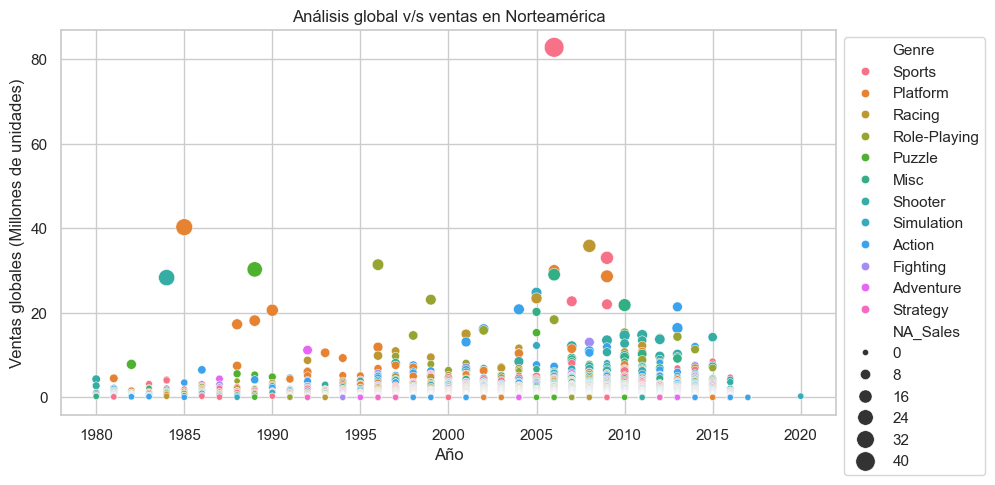

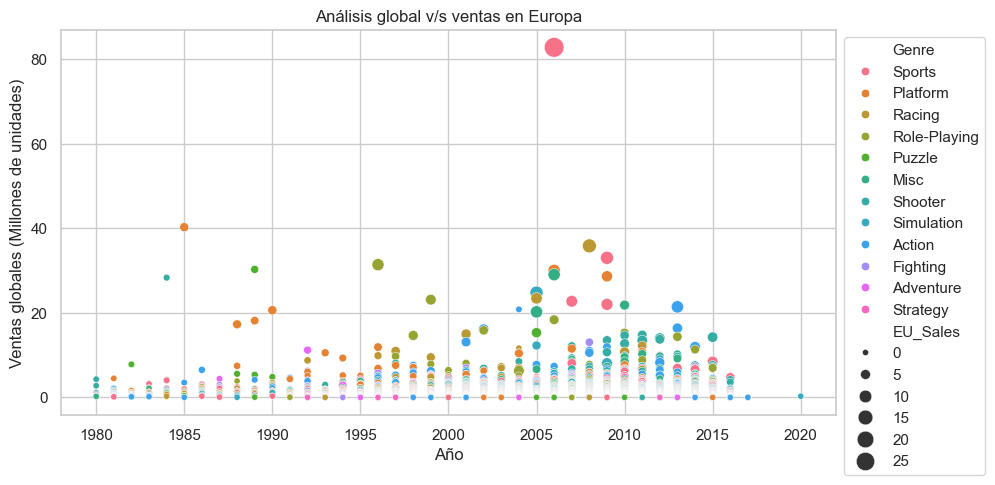

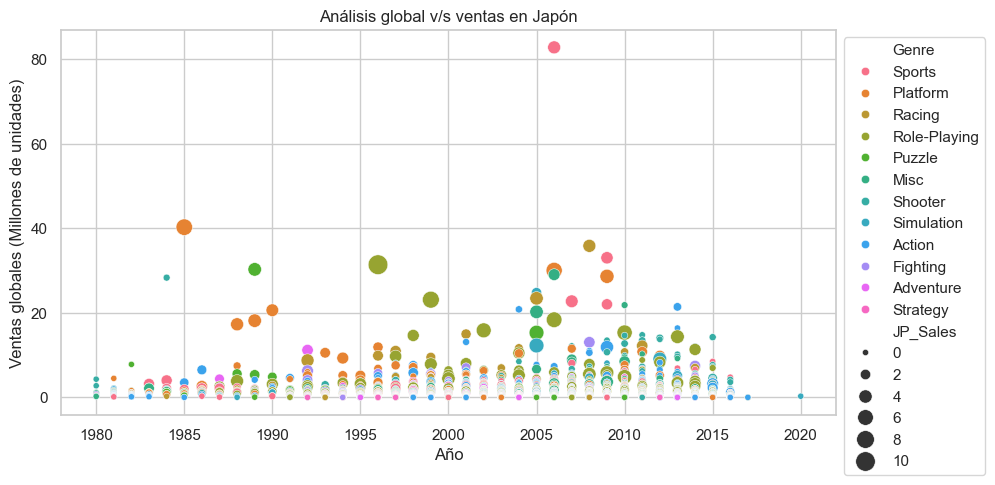

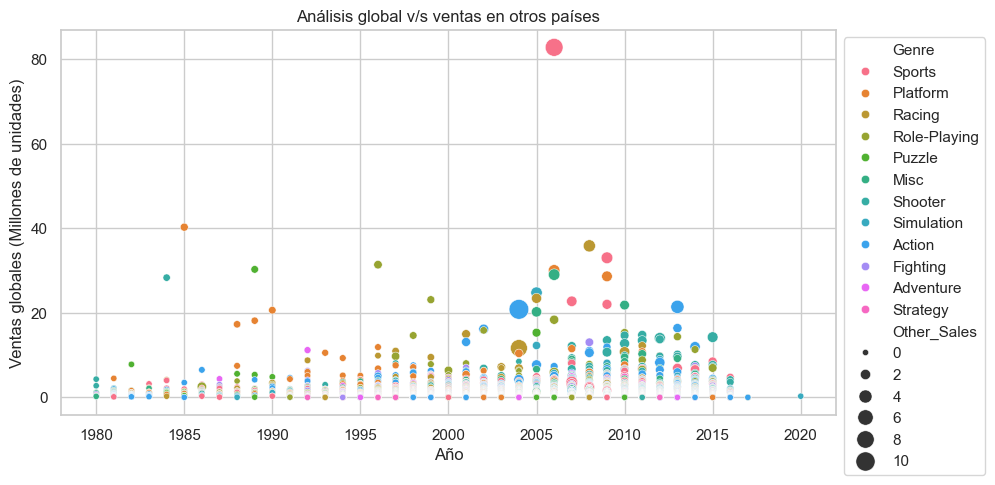

In [23]:
# Se crea un diccionario para traducir los nombres "técnicos" a nombres fáciles de leer.
regiones= {'NA_Sales': 'ventas en Norteamérica', 'EU_Sales': 'ventas en Europa', 'JP_Sales': 'ventas en Japón', 'Other_Sales': 'ventas en otros países'}

# Usamos un bucle para crear un gráfico para cada región.
for region in regiones.keys():

    # Tamaño del lienzo del gráfico.
    plt.figure(figsize= (10, 5))

    # Se dibujan los puntos y ajustes visuales.
    sns.scatterplot(data= data, x= 'Year', y= 'Global_Sales', hue= 'Genre', size= region, sizes= (20, 200), alpha= 1.0)
    titulo= regiones[region]

    # Pone el título y los nombres de los ejes.
    plt.title(f'Análisis global v/s {titulo}')
    plt.xlabel("Año")
    plt.ylabel("Ventas globales (Millones de unidades)")
    
    # Se mueve el cuadro explicativo afuera del gráfico y se muestra el resultado.
    plt.legend(bbox_to_anchor= (1, 1), loc= 'upper left')
    plt.show()

En estos gráficos se puede ver cómo el éxito no es igual para todos los juegos. Los puntos más grandes representan los títulos que fueron un fenómeno en su región. Lo más llamativo es que en Norteamérica y Europa, los grandes éxitos (los círculos más grandes) están muy dispersos entre Action y Sports, mientras que en Japón hay una concentración única de círculos importantes en el género Role-Playing. Esto demuestra que el mercado japonés no solo prefiere los Role-Playing, sino que los consume de forma masiva y constante a diferencia del resto del mundo.

# Formulación de la pregunta de investigación:

En base al trabajo realizado anteriormente, centraremos nuestro análisis en estudiar la relación entre el género de los videojuegos y su desempeño en las ventas, considerando además las diferencias de las otras regiones en el mercado. Especialmente, se pondrá atención al caso de Japón, con el propósito de observar si este mercado presenta un comportamiento distinto al de las otras regiones más relevantes dentro de la industria de los videojuegos.

A partir de esto, se buscará responder la siguiente pregunta de investigación: 

¿La relación entre el género y las ventas de videojuegos cambia según la región, siendo Japón una de las regiones con un comportamiento más notorio?